# SPACESHIP TITANIC

In [413]:
import copy
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression


## Data Import

In [414]:
train_data = pd.read_csv("./data/train.csv")
test_data = pd.read_csv("./data/test.csv")

## Data Preprocess
- Transported/CryoSleep 轉成 0/1
- PassengerId、Name、Cabin 原始欄位不直接當特徵
- PassengerId / Name 會衍生群組特徵
- RoomService / FoodCourt / ShoppingMall / Spa / VRDeck 會衍生消費聚合特徵
- Age 會另外切成幾個 age bins
- Cabin 缺失值補上 Missing//Missing
    - 把 Cabin 拆成 CabinDeck、CabinNum、CabinSide

In [415]:
def to_binary(series):
    return series.astype(str).map({"False": 0, "True": 1}).astype(float)


def add_basic_features(df):
    df = df.copy()

    passenger_group = (
        df["PassengerId"]
        .astype("string")
        .fillna("Missing")
        .str.split("_", n=1, expand=True)[0]
    )
    passenger_group_size = passenger_group.map(passenger_group.value_counts()).astype(float)
    df["PassengerGroupSize"] = passenger_group_size
    df["PassengerIsAlone"] = (passenger_group_size == 1).astype(float)

    age_numeric = pd.to_numeric(df["Age"], errors="coerce")
    age_bins = [-np.inf, 12, 17, 25, 40, 60, np.inf]
    age_labels = ["Child", "Teen", "YoungAdult", "Adult", "MiddleAged", "Senior"]
    df["AgeBin"] = pd.cut(age_numeric, bins=age_bins, labels=age_labels, include_lowest=True).astype("string").fillna("Missing")

    surname = (
        df["Name"]
        .astype("string")
        .fillna("Missing")
        .str.rsplit(" ", n=1)
        .str[-1]
    )
    surname_group_size = surname.map(surname.value_counts()).astype(float)
    df["SurnameGroupSize"] = surname_group_size
    df["SurnameIsAlone"] = (surname_group_size == 1).astype(float)

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    spend_frame = df[spend_cols].fillna(0)
    df["TotalSpend"] = spend_frame.sum(axis=1)
    df["LogTotalSpend"] = np.log1p(df["TotalSpend"])
    df["AnySpend"] = (df["TotalSpend"] > 0).astype(float)
    df["LuxurySpend"] = spend_frame[["Spa", "VRDeck"]].sum(axis=1)
    df["RegularSpend"] = spend_frame[["RoomService", "FoodCourt", "ShoppingMall"]].sum(axis=1)

    df = df.drop(columns=["PassengerId", "Name"], errors="ignore")
    cabin = df["Cabin"].fillna("Missing//Missing").str.split("/", expand=True)
    df["CabinDeck"] = cabin[0]
    df["CabinNum"] = pd.to_numeric(cabin[1], errors="coerce")
    df["CabinSide"] = cabin[2]
    return df.drop(columns=["Cabin"])


# Split train / validation first.
X = train_data.drop(columns=["Transported"]).copy()
y = to_binary(train_data["Transported"])
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = add_basic_features(X_train)
X_val = add_basic_features(X_val)

## Baseline 0
先看一個最簡單的 `Transported = CryoSleep` validation accuracy
- 把 validation set 裡 CryoSleep 的缺失值，補成算出的眾數

In [416]:
# 先從 training split 的 CryoSleep 找出最常出現的值
cryo_mode = X_train["CryoSleep"].mode(dropna=True)[0]
# 把 validation split 裡 CryoSleep 的缺失值，補成剛剛算出的眾數
cryo_val = X_val["CryoSleep"].astype("string").fillna(cryo_mode)
cryo_pred = to_binary(cryo_val)
# 直接算 accuracy
acc_b0 = accuracy_score(y_val, cryo_pred >= 0.5)
print(f"Baseline 0 | Transported = CryoSleep | Acc: {acc_b0:.4f}")

Baseline 0 | Transported = CryoSleep | Acc: 0.7131


## CatBoost
CatBoost fit training split, then evaluate validation accuracy and logloss.

In [417]:
from catboost import CatBoostClassifier


def to_dense_matrix(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


# CatBoost does not need scaling, so we only impute missing values and one-hot encode categoricals.
cat_numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

cat_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), cat_numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_categorical_features,
        ),
    ]
)

X_train_pre = cat_preprocess.fit_transform(X_train)
X_val_pre = cat_preprocess.transform(X_val)
cat_feature_names = cat_preprocess.get_feature_names_out()

# Keep the feature screen compact, then let CatBoost learn on the selected columns.
SELECT_K = 40
N_ESTIMATORS = 10000
LR = 0.01
MAX_DEPTH = 5
SUBSAMPLE = 0.65
COLSAMPLE_BYTREE = 0.9
CATBOOST_L2_LEAF_REG = 3.0
ESR = 200


cat_k = min(SELECT_K, X_train_pre.shape[1])
selector = SelectKBest(score_func=f_regression, k=cat_k)
X_train_sel = selector.fit_transform(X_train_pre, y_train)
X_val_sel = selector.transform(X_val_pre)
X_train_sel_dense = to_dense_matrix(X_train_sel)
X_val_sel_dense = to_dense_matrix(X_val_sel)
selected_cat_feature_names = cat_feature_names[selector.get_support()]

print(f"SELECT_K = {cat_k}")
print(f"preprocessed feature count = {X_train_pre.shape[1]}")
print(f"selected feature count = {len(selected_cat_feature_names)}")
print("selected features:")
print(list(selected_cat_feature_names))

cat_model = CatBoostClassifier(
    iterations=N_ESTIMATORS,
    learning_rate=LR,
    depth=MAX_DEPTH,
    subsample=SUBSAMPLE,
    rsm=COLSAMPLE_BYTREE,
    l2_leaf_reg=CATBOOST_L2_LEAF_REG,
    random_seed=42,
    loss_function="Logloss",
    eval_metric="Logloss",
    bootstrap_type="Bernoulli",
    verbose=False,
    allow_writing_files=False,
    use_best_model=True,
    od_type="Iter",
    od_wait=ESR,
)
cat_model.fit(
    X_train_sel_dense,
    y_train.astype(int),
    eval_set=(X_val_sel_dense, y_val.astype(int)),
    verbose=False,
)
train_acc_cat = accuracy_score(y_train.astype(int), np.asarray(cat_model.predict(X_train_sel_dense)).astype(int).ravel())
val_acc_cat = accuracy_score(y_val.astype(int), np.asarray(cat_model.predict(X_val_sel_dense)).astype(int).ravel())
evals_result = cat_model.get_evals_result()
print(f"CatBoost | train acc: {train_acc_cat:.4f} | val acc: {val_acc_cat:.4f}")
print(f"best_iteration = {cat_model.get_best_iteration()}")
print(f"best_score = {cat_model.get_best_score()}")

SELECT_K = 40
preprocessed feature count = 45
selected feature count = 40
selected features:
['num__Age', 'num__RoomService', 'num__FoodCourt', 'num__Spa', 'num__VRDeck', 'num__PassengerGroupSize', 'num__PassengerIsAlone', 'num__SurnameIsAlone', 'num__TotalSpend', 'num__LogTotalSpend', 'num__AnySpend', 'num__LuxurySpend', 'num__RegularSpend', 'num__CabinNum', 'cat__HomePlanet_Earth', 'cat__HomePlanet_Europa', 'cat__HomePlanet_Mars', 'cat__CryoSleep_False', 'cat__CryoSleep_True', 'cat__Destination_55 Cancri e', 'cat__Destination_TRAPPIST-1e', 'cat__VIP_False', 'cat__VIP_True', 'cat__AgeBin_Adult', 'cat__AgeBin_Child', 'cat__AgeBin_MiddleAged', 'cat__AgeBin_Missing', 'cat__AgeBin_Senior', 'cat__AgeBin_Teen', 'cat__AgeBin_YoungAdult', 'cat__CabinDeck_B', 'cat__CabinDeck_C', 'cat__CabinDeck_D', 'cat__CabinDeck_E', 'cat__CabinDeck_F', 'cat__CabinDeck_G', 'cat__CabinDeck_T', 'cat__CabinSide_Missing', 'cat__CabinSide_P', 'cat__CabinSide_S']
CatBoost | train acc: 0.8840 | val acc: 0.8068
best_

# CatBoost + OOF Threshold Search
- 先做缺值補齊 + one-hot
- 用 SelectKBest(f_regression) 選特徵
- 直接用外層 X_val 做 early stopping，看收斂狀況
- 用 OOF probabilities 找最佳 threshold
- 最後用 full training data 重訓再輸出 submission

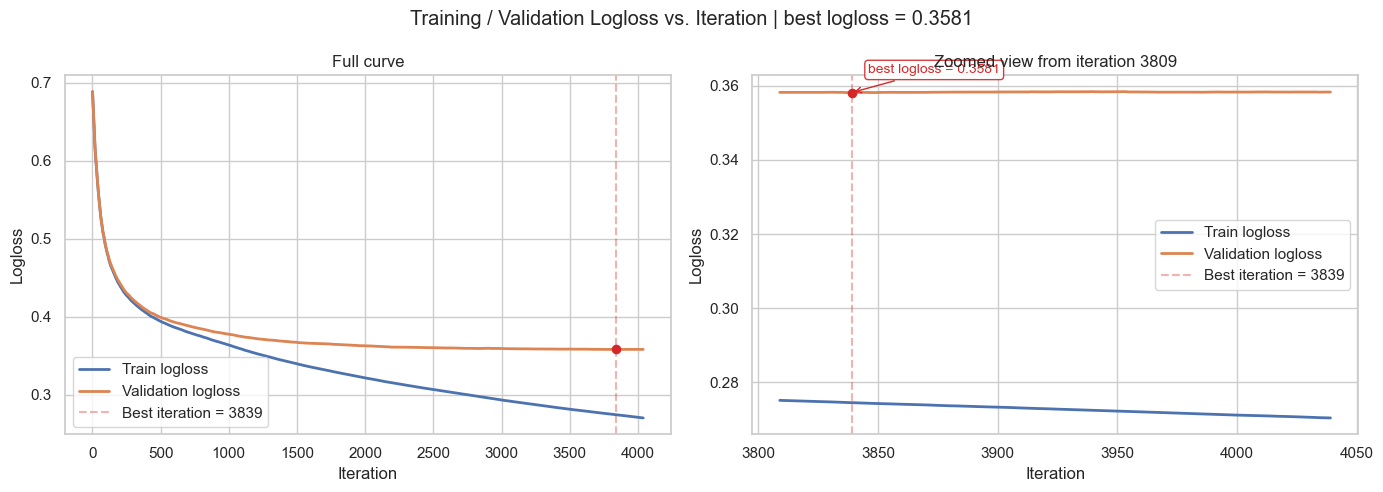

In [418]:
# evals_result is populated in the previous CatBoost training cell.
def _extract_catboost_metric_series(evals_result, metric_name="Logloss"):
    train_key = "learn" if "learn" in evals_result else next(iter(evals_result))
    val_key = next((key for key in evals_result.keys() if key != train_key), train_key)
    train_metrics = evals_result[train_key]
    val_metrics = evals_result[val_key]
    if metric_name not in train_metrics:
        metric_name = next(iter(train_metrics))
    return train_metrics[metric_name], val_metrics[metric_name]

train_logloss, val_logloss = _extract_catboost_metric_series(evals_result)
rounds = np.arange(1, len(train_logloss) + 1)
best_iteration = cat_model.get_best_iteration()
best_round = (best_iteration + 1) if best_iteration is not None and best_iteration >= 0 else int(np.argmin(val_logloss) + 1)
best_idx = best_round - 1
best_val_logloss = val_logloss[best_idx]
zoom_start = max(1, best_round - 30)
zoom_mask = rounds >= zoom_start
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, train_logloss, label='Train logloss', linewidth=2)
axes[0].plot(rounds, val_logloss, label='Validation logloss', linewidth=2)
axes[0].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best iteration = {best_round}')
axes[0].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Logloss')
axes[0].set_title('Full curve')
axes[0].legend()

axes[1].plot(rounds[zoom_mask], np.array(train_logloss)[zoom_mask], label='Train logloss', linewidth=2)
axes[1].plot(rounds[zoom_mask], np.array(val_logloss)[zoom_mask], label='Validation logloss', linewidth=2)
axes[1].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best iteration = {best_round}')
axes[1].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[1].annotate(
    f'best logloss = {best_val_logloss:.4f}',
    xy=(best_round, best_val_logloss),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Logloss')
axes[1].set_title(f'Zoomed view from iteration {zoom_start}')
axes[1].legend()

fig.suptitle(f'Training / Validation Logloss vs. Iteration | best logloss = {best_val_logloss:.4f}')
fig.tight_layout()
plt.show()

## Final Run
Retrain a single CatBoost model on the full training data, search OOF threshold, and submit from inside the notebook.

In [419]:
# Final run: retrain a single CatBoost model on the full training set, search an OOF threshold, write submission.csv, and submit from inside this notebook.
import subprocess
import sys
import shutil
from pathlib import Path
from catboost import CatBoostClassifier


def to_dense_matrix(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


def build_cat_preprocess(X_fit):
    numeric_features = X_fit.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_fit.select_dtypes(exclude=["number"]).columns.tolist()
    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                categorical_features,
            ),
        ]
    )


def fit_single_catboost(X_fit, y_fit, X_target, n_estimators, *, random_state=42):
    preprocess = build_cat_preprocess(X_fit)
    X_fit_pre = preprocess.fit_transform(X_fit)
    X_target_pre = preprocess.transform(X_target)
    feature_names = preprocess.get_feature_names_out()
    k_eff = min(SELECT_K, X_fit_pre.shape[1])
    selector = SelectKBest(score_func=f_regression, k=k_eff)
    X_fit_sel = to_dense_matrix(selector.fit_transform(X_fit_pre, y_fit))
    X_target_sel = to_dense_matrix(selector.transform(X_target_pre))
    selected_feature_names = feature_names[selector.get_support()]

    model = CatBoostClassifier(
        iterations=n_estimators,
        learning_rate=LR,
        depth=MAX_DEPTH,
        subsample=SUBSAMPLE,
        rsm=COLSAMPLE_BYTREE,
        l2_leaf_reg=CATBOOST_L2_LEAF_REG,
        random_seed=random_state,
        loss_function="Logloss",
        eval_metric="Logloss",
        bootstrap_type="Bernoulli",
        verbose=False,
        allow_writing_files=False,
    )
    model.fit(X_fit_sel, y_fit.astype(int), verbose=False)
    return model, selected_feature_names, X_target_sel


def search_best_threshold(y_true, probas, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 197)
    y_true = np.asarray(y_true).astype(int)
    probas = np.asarray(probas)
    best_threshold = 0.5
    best_acc = -1.0
    for threshold in thresholds:
        acc = accuracy_score(y_true, probas >= threshold)
        if acc > best_acc:
            best_acc = acc
            best_threshold = float(threshold)
    return best_threshold, best_acc


def build_oof_catboost_predictions(X, y, n_estimators, *, n_splits=5, random_state=42):
    X_work = X.reset_index(drop=True)
    y_work = np.asarray(y).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_proba = np.zeros(len(X_work), dtype=float)
    selected_counts = []
    for fold_idx, (fit_idx, eval_idx) in enumerate(skf.split(X_work, y_work)):
        X_fit = X_work.iloc[fit_idx].reset_index(drop=True)
        y_fit = y_work[fit_idx]
        X_eval = X_work.iloc[eval_idx].reset_index(drop=True)
        y_eval = y_work[eval_idx]
        model, selected_feature_names, X_eval_sel = fit_single_catboost(
            X_fit,
            y_fit,
            X_eval,
            n_estimators,
            random_state=random_state + fold_idx,
        )
        fold_proba = model.predict_proba(X_eval_sel)[:, 1]
        oof_proba[eval_idx] = fold_proba
        selected_counts.append(len(selected_feature_names))
        print(
            f"fold={fold_idx + 1}/{n_splits} | oof acc @0.5: {accuracy_score(y_eval, fold_proba >= 0.5):.4f} | "
            f"selected: {len(selected_feature_names)}"
        )
    return oof_proba, selected_counts


final_iterations = int(globals().get("best_round", N_ESTIMATORS))
print(f"final_iterations = {final_iterations}")

full_train_X = add_basic_features(train_data.drop(columns=["Transported"]).copy())
full_train_y = to_binary(train_data["Transported"])
test_raw = add_basic_features(test_data.copy())

oof_proba, oof_selected_counts = build_oof_catboost_predictions(
    full_train_X,
    full_train_y,
    final_iterations,
    n_splits=5,
    random_state=42,
)
full_train_y_int = np.asarray(full_train_y).astype(int)
oof_acc_05 = accuracy_score(full_train_y_int, oof_proba >= 0.5)
best_threshold, best_oof_acc = search_best_threshold(full_train_y_int, oof_proba)
print(f"OOF acc @0.5: {oof_acc_05:.4f}")
print(f"OOF best threshold: {best_threshold:.4f} | OOF best acc: {best_oof_acc:.4f}")
print(f"OOF selected feature counts = {oof_selected_counts}")

final_model, final_selected_feature_names, X_test_sel = fit_single_catboost(
    full_train_X,
    full_train_y,
    test_raw,
    final_iterations,
    random_state=42,
)
print(f"selected feature count = {len(final_selected_feature_names)}")
print(list(final_selected_feature_names))

test_proba = final_model.predict_proba(X_test_sel)[:, 1]
test_pred = (test_proba >= best_threshold).astype(bool)

k_tag = f"k{SELECT_K}"
submission_path = (
    f"submission_catboost_single_{k_tag}_it{final_iterations}_th{fmt_param(best_threshold)}"
    f"_lr{fmt_param(LR)}_md{MAX_DEPTH}_ss{fmt_param(SUBSAMPLE)}"
    f"_cs{fmt_param(COLSAMPLE_BYTREE)}_l2{fmt_param(CATBOOST_L2_LEAF_REG)}"
    f".csv"
)

sample_submission = pd.read_csv("./data/sample_submission.csv")
submission = sample_submission.copy()
submission["Transported"] = test_pred
submission.to_csv(submission_path, index=False)

print(submission.head())
print(f"saved to {submission_path} with shape {submission.shape}")

kaggle_exe = shutil.which("kaggle") or str(Path(sys.executable).with_name("kaggle"))
submit_cmd = [
    kaggle_exe,
    "competitions",
    "submit",
    "-c",
    "spaceship-titanic",
    "-f",
    submission_path,
    "-m",
    f"CatBoost model / flat SelectKBest / PassengerId & Name features process / Spend features process / age bins / OOF threshold search",
]
print("Running:", " ".join(submit_cmd))
try:
    result = subprocess.run(submit_cmd, check=True, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
except FileNotFoundError:
    print("kaggle CLI not found in this notebook kernel environment.")
except subprocess.CalledProcessError as exc:
    print("Kaggle submit failed.")
    if exc.stdout:
        print(exc.stdout)
    if exc.stderr:
        print(exc.stderr)
    raise

final_iterations = 3839
fold=1/5 | oof acc @0.5: 0.8137 | selected: 40
fold=2/5 | oof acc @0.5: 0.8189 | selected: 40
fold=3/5 | oof acc @0.5: 0.8108 | selected: 40
fold=4/5 | oof acc @0.5: 0.8285 | selected: 40
fold=5/5 | oof acc @0.5: 0.8038 | selected: 40
OOF acc @0.5: 0.8151
OOF best threshold: 0.4950 | OOF best acc: 0.8163
OOF selected feature counts = [40, 40, 40, 40, 40]
selected feature count = 40
['num__Age', 'num__RoomService', 'num__FoodCourt', 'num__ShoppingMall', 'num__Spa', 'num__VRDeck', 'num__PassengerGroupSize', 'num__PassengerIsAlone', 'num__SurnameGroupSize', 'num__SurnameIsAlone', 'num__TotalSpend', 'num__LogTotalSpend', 'num__AnySpend', 'num__LuxurySpend', 'num__RegularSpend', 'num__CabinNum', 'cat__HomePlanet_Earth', 'cat__HomePlanet_Europa', 'cat__HomePlanet_Mars', 'cat__CryoSleep_False', 'cat__CryoSleep_True', 'cat__Destination_55 Cancri e', 'cat__Destination_TRAPPIST-1e', 'cat__VIP_False', 'cat__VIP_True', 'cat__AgeBin_Adult', 'cat__AgeBin_Child', 'cat__AgeBin_